# Swin Transformer + SE Block — Ablation Study (PyTorch)
## Anti-Overfitting Version — Chest X-Ray Pneumonia

### Fixes applied
| Problem | Fix |
|---------|-----|
| Train 100% / Val 81% → overfitting | Downsampling + L2 reg + Dropout + Label Smoothing + Freeze backbone |
| `AttributeError: 'Image' has no .shape` | `RandomErasing` moved **after** `ToTensor()` |
| Class imbalance | Random undersampling of PNEUMONIA (majority) |

### Ablation variants
| Variant | SE Block | Preprocessing |
|---------|----------|---------------|
| A | No | Baseline (with downsampling) |
| B | Yes | Baseline (with downsampling) |
| C | No | Augmented |
| D | Yes | Augmented |

## Imports

In [1]:
import os, time, math, random, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm   : {timm.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128
timm   : 1.0.25


## Dataset Download

In [2]:
import kagglehub
dl_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

BASE_DIR = dl_path
for root, dirs, _ in os.walk(dl_path):
    if all(f in dirs for f in ['train','test','val']):
        BASE_DIR = root; break

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
print('Base:', BASE_DIR)

Base: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## EDA

Class  NORMAL  PNEUMONIA  Total
Split                          
test      234        390    624
train    1341       3875   5216
val         8          8     16
Total    1583       4273   5856


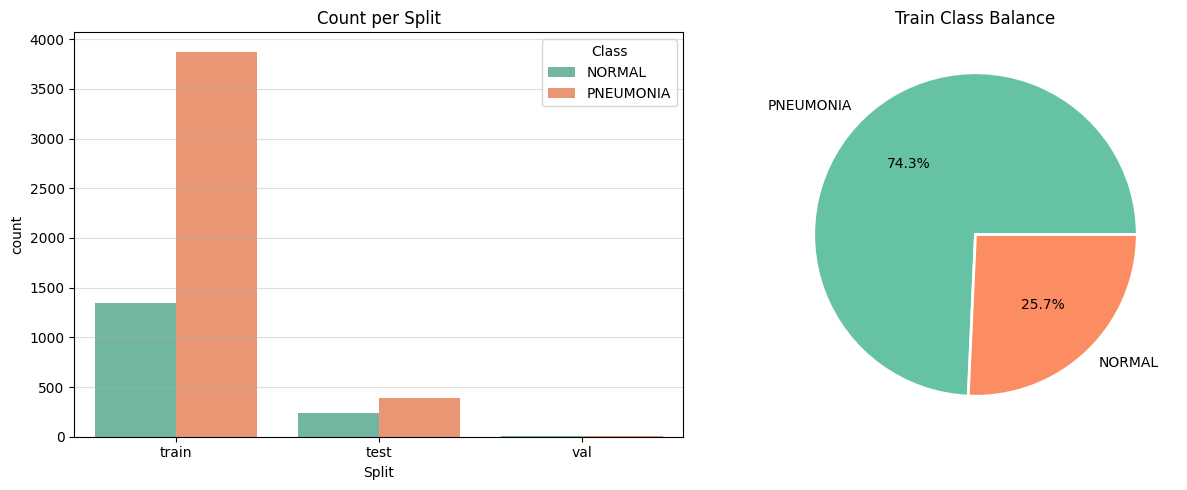

In [3]:
rows = []
for split in ['train','test','val']:
    for cls in CLASS_NAMES:
        d = os.path.join(BASE_DIR, split, cls)
        if not os.path.exists(d): continue
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                rows.append({'Split':split,'Class':cls,
                             'Path':os.path.join(d,f)})
df = pd.DataFrame(rows)
print(pd.crosstab(df['Split'], df['Class'], margins=True, margins_name='Total'))

fig, ax = plt.subplots(1, 2, figsize=(13,5))
sns.countplot(data=df, x='Split', hue='Class', palette='Set2', ax=ax[0])
ax[0].set_title('Count per Split'); ax[0].grid(axis='y', alpha=0.4)
counts = df[df['Split']=='train']['Class'].value_counts()
ax[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
          colors=['#66c2a5','#fc8d62'],
          wedgeprops={'edgecolor':'white','linewidth':2})
ax[1].set_title('Train Class Balance')
plt.tight_layout(); plt.show()

## Dataset Class with CLAHE
Custom `Dataset` that applies CLAHE during `__getitem__`.

In [4]:
class XRayDataset(Dataset):
    """
    Loads chest X-ray images from CLASS_NAME subdirectories.
    Applies CLAHE + Gaussian blur in __getitem__ before the torchvision transform.
    """
    def __init__(self, root_dir, class_names, transform=None):
        self.transform    = transform
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples      = []

        for cls in class_names:
            d = os.path.join(root_dir, cls)
            if not os.path.exists(d): continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append(
                        (os.path.join(d, f), self.class_to_idx[cls])
                    )

        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.samples)

    def _apply_clahe(self, img_rgb: np.ndarray) -> Image.Image:
        """CLAHE on L-channel (LAB) + Gaussian blur. Returns PIL Image."""
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lab[:,:,0] = self._clahe.apply(lab[:,:,0])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        out = cv2.GaussianBlur(out, (3,3), sigmaX=0.5)
        return Image.fromarray(out)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil_img = self._apply_clahe(img_rgb)   # PIL Image after CLAHE
        if self.transform:
            pil_img = self.transform(pil_img)  # torchvision transforms
        return pil_img, label

    @property
    def targets(self):
        return [s[1] for s in self.samples]


print('XRayDataset defined.')

XRayDataset defined.


## Preprocessing & Augmentation Transforms

### Bug fix: `RandomErasing` must come AFTER `ToTensor()`
PIL Images do not have `.shape` — `RandomErasing` needs a tensor.

### Anti-overfitting additions
- `RandomErasing` (after ToTensor — **fixed**)
- `MixUp` applied at batch level in training loop
- `Label Smoothing` in loss function
- `L2 weight decay` in AdamW
- `Dropout` in the classification head
- **Backbone frozen** for first N epochs, then gradually unfrozen

In [5]:
IMG_SIZE   = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Baseline transform (no augmentation) ──────────────────────────────────────
# NOTE: RandomErasing is AFTER ToTensor — works on tensors, not PIL
baseline_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),                          # PIL → tensor (C,H,W) float [0,1]
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Augmented transform (training only) ───────────────────────────────────────
augmented_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(degrees=12),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ToTensor(),                                    # ← PIL → tensor HERE
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02,0.12),       # ← AFTER ToTensor (FIXED)
                   ratio=(0.3, 3.3), value=0),
])

# ── Test/val transform ────────────────────────────────────────────────────────
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined (RandomErasing correctly placed after ToTensor).')

Transforms defined (RandomErasing correctly placed after ToTensor).


## Preprocessing Visualization

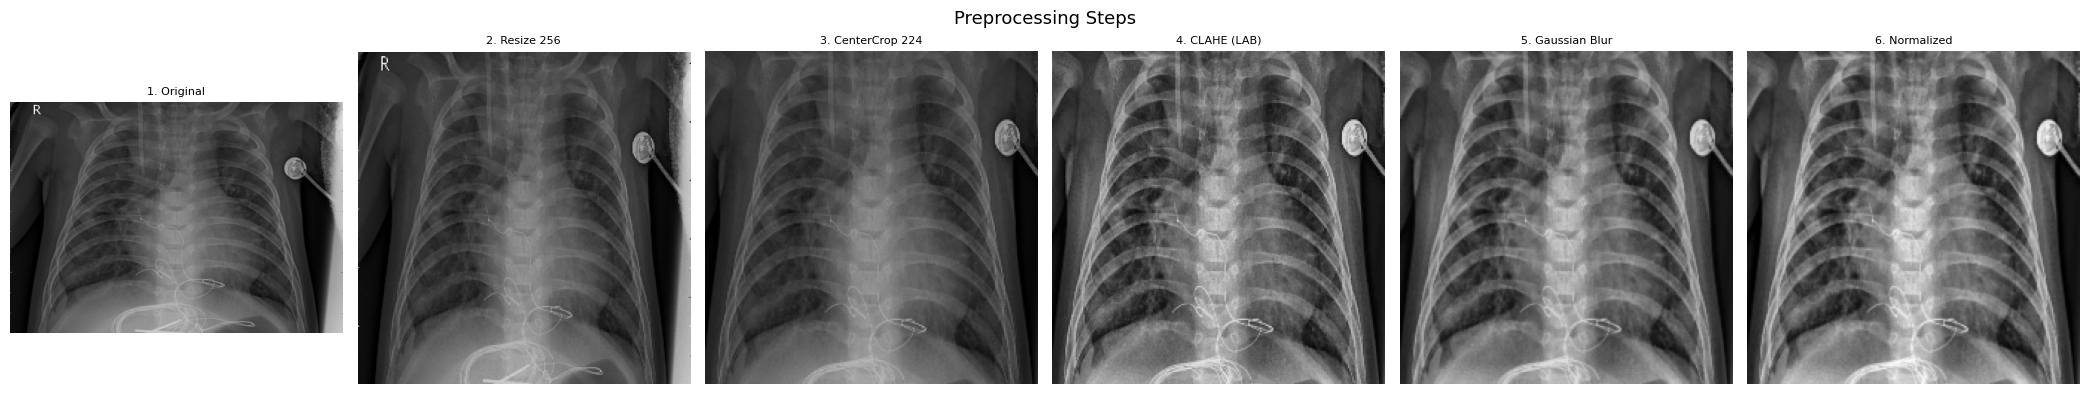

In [6]:
def show_preprocess_steps(img_path):
    bgr      = cv2.imread(img_path)
    original = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized  = cv2.resize(original, (256,256))
    m        = (256 - 224) // 2
    cropped  = resized[m:m+224, m:m+224]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab   = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    clahe_img  = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    blurred    = cv2.GaussianBlur(clahe_img, (3,3), 0.5)
    norm       = blurred.astype(np.float32)/255.0
    norm_vis   = ((norm-norm.min())/(norm.max()-norm.min())*255).astype(np.uint8)

    steps = [
        ('1. Original',      original),
        ('2. Resize 256',    resized),
        ('3. CenterCrop 224',cropped),
        ('4. CLAHE (LAB)',   clahe_img),
        ('5. Gaussian Blur', blurred),
        ('6. Normalized',    norm_vis),
    ]
    fig, axes = plt.subplots(1, 6, figsize=(21, 4))
    fig.suptitle('Preprocessing Steps', fontsize=13)
    for ax, (t, im) in zip(axes, steps):
        ax.imshow(im); ax.set_title(t, fontsize=8); ax.axis('off')
    plt.tight_layout(); plt.show()

sample_path = df[(df['Split']=='train')&(df['Class']=='PNEUMONIA')]['Path'].iloc[0]
show_preprocess_steps(sample_path)

## Augmentation Visualization

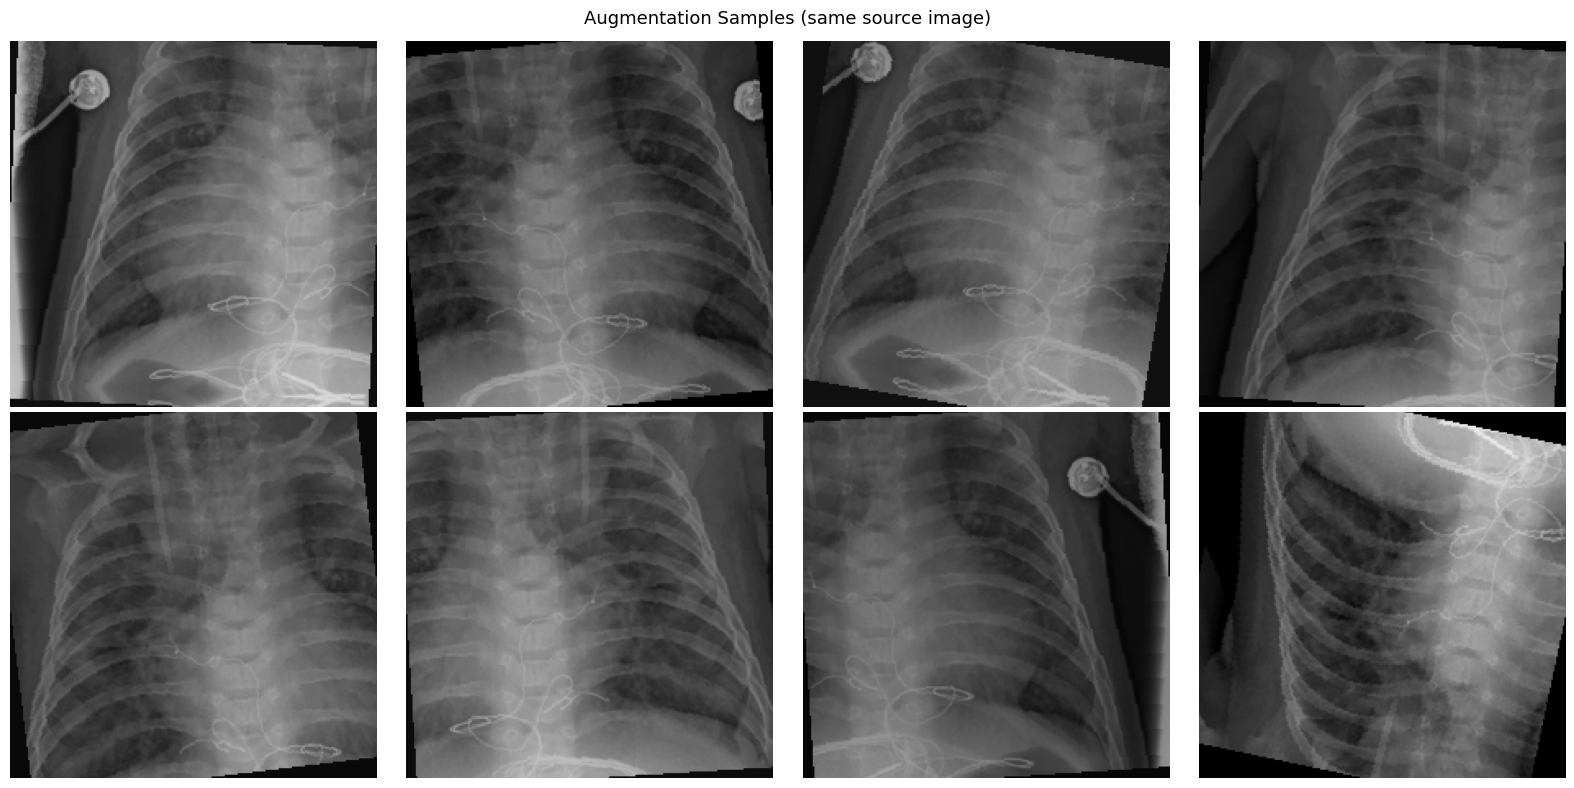

In [7]:
def show_augmentations(img_path, n=8):
    # Re-create augmentation pipeline WITHOUT Normalize for display
    aug_display = T.Compose([
        T.Resize(256),
        T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.1),
        T.RandomRotation(12),
        T.ColorJitter(brightness=0.2, contrast=0.2),
    ])
    pil = Image.fromarray(
        cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    )
    fig, axes = plt.subplots(2, n//2, figsize=(16,8))
    fig.suptitle('Augmentation Samples (same source image)', fontsize=13)
    for ax in axes.flat:
        ax.imshow(aug_display(pil)); ax.axis('off')
    plt.tight_layout(); plt.show()

show_augmentations(sample_path)

## Downsampling — Anti-Overfitting / Class Balance

**Why downsampling?**
- Original: NORMAL=1341, PNEUMONIA=3875 (2.9× imbalance)
- Model memorizes the majority class → overfitting
- **Random undersampling** of PNEUMONIA to match NORMAL count
- Reduces total training samples → faster epochs, less memorization risk

**Combined strategy:** Downsample + class-weighted loss

In [8]:
def build_balanced_subset(dataset, seed=SEED):
    """
    Random undersampling: reduces the majority class to match minority.
    Returns a Subset with balanced class counts.
    """
    targets = dataset.targets
    indices_by_class = {}
    for idx, lbl in enumerate(targets):
        indices_by_class.setdefault(lbl, []).append(idx)

    min_count = min(len(v) for v in indices_by_class.values())
    rng = random.Random(seed)

    balanced_indices = []
    for cls, idxs in indices_by_class.items():
        sampled = rng.sample(idxs, min_count)
        balanced_indices.extend(sampled)

    rng.shuffle(balanced_indices)

    counts = Counter([targets[i] for i in balanced_indices])
    print(f'  Balanced dataset: {dict(counts)} (total={len(balanced_indices)})')
    return Subset(dataset, balanced_indices)


# ── Build full datasets ────────────────────────────────────────────────────────
full_train_base = XRayDataset(TRAIN_DIR, CLASS_NAMES, transform=baseline_transform)
full_train_aug  = XRayDataset(TRAIN_DIR, CLASS_NAMES, transform=augmented_transform)
test_ds         = XRayDataset(TEST_DIR,  CLASS_NAMES, transform=test_transform)

print(f'Full train: {len(full_train_base)} | Test: {len(test_ds)}')
print(f'Train class dist: {Counter(full_train_base.targets)}')

# ── Downsample both baseline and augmented training sets ─────────────────────
print('\nDownsampling training sets...')
print('Baseline:'); train_base_balanced = build_balanced_subset(full_train_base)
print('Augmented:'); train_aug_balanced  = build_balanced_subset(full_train_aug)

# ── DataLoaders ────────────────────────────────────────────────────────────────
def make_loader(dataset, shuffle=True):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=4, pin_memory=True, persistent_workers=True)

train_loader_base = make_loader(train_base_balanced, shuffle=True)
train_loader_aug  = make_loader(train_aug_balanced,  shuffle=True)
test_loader       = make_loader(test_ds, shuffle=False)

print(f'\nLoaders ready.')
print(f'  Train base batches: {len(train_loader_base)}')
print(f'  Train aug  batches: {len(train_loader_aug)}')
print(f'  Test  batches     : {len(test_loader)}')

Full train: 5216 | Test: 624
Train class dist: Counter({1: 3875, 0: 1341})

Downsampling training sets...
Baseline:
  Balanced dataset: {1: 1341, 0: 1341} (total=2682)
Augmented:
  Balanced dataset: {1: 1341, 0: 1341} (total=2682)

Loaders ready.
  Train base batches: 84
  Train aug  batches: 84
  Test  batches     : 20


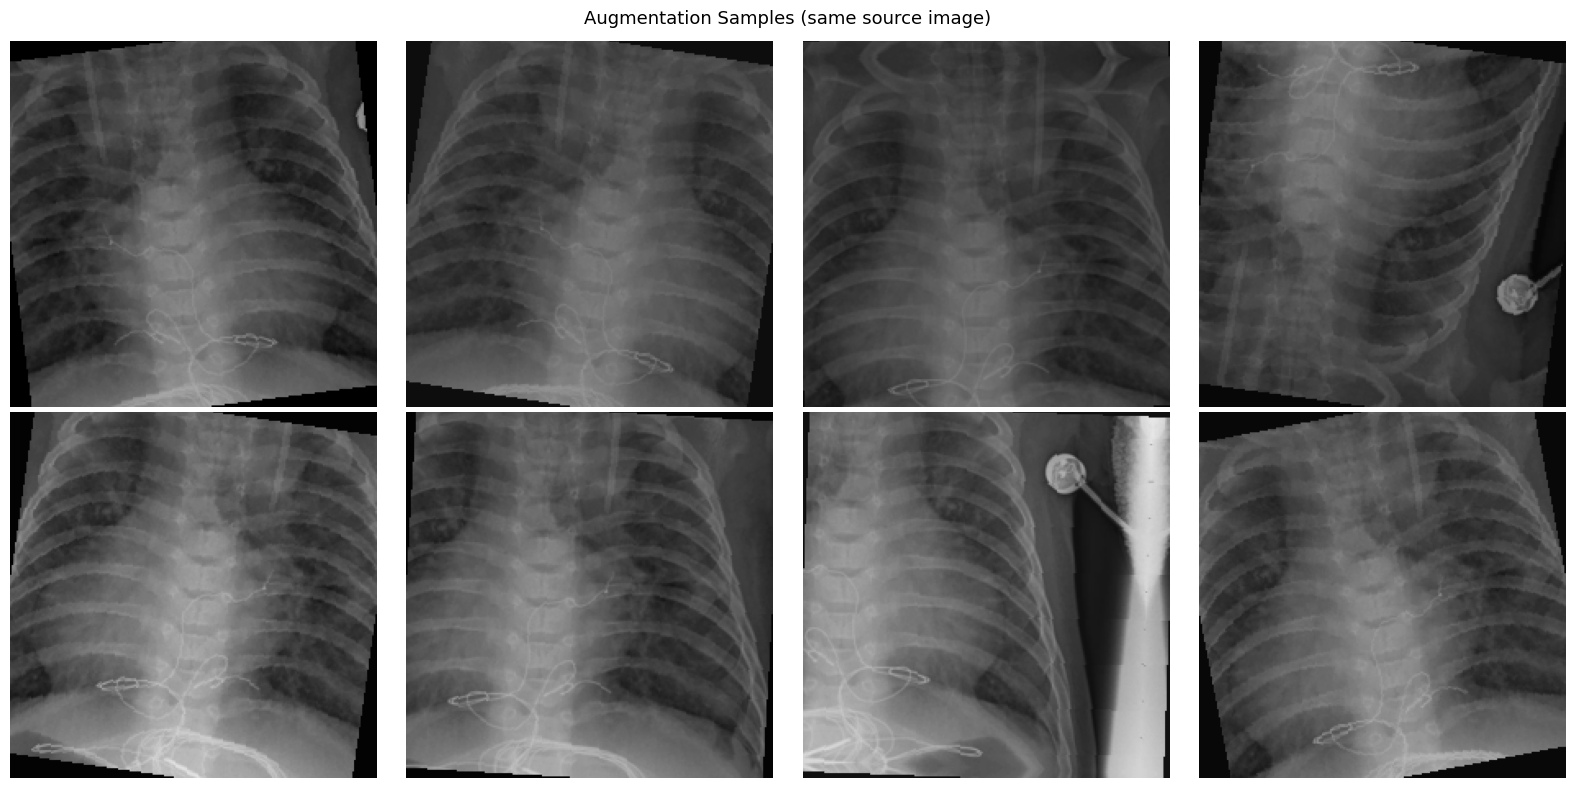

In [9]:
def show_augmentations(img_path, n=8):
    # Re-create augmentation pipeline WITHOUT Normalize for display
    aug_display = T.Compose([
        T.Resize(256),
        T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.1),
        T.RandomRotation(12),
        T.ColorJitter(brightness=0.2, contrast=0.2),
    ])
    pil = Image.fromarray(
        cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    )
    fig, axes = plt.subplots(2, n//2, figsize=(16,8))
    fig.suptitle('Augmentation Samples (same source image)', fontsize=13)
    for ax in axes.flat:
        ax.imshow(aug_display(pil)); ax.axis('off')
    plt.tight_layout(); plt.show()

show_augmentations(sample_path)

## SE Block

Implements `tfm.vision.layers.SqueezeExcitation` in PyTorch:

```
x (B,C,H,W)
 → AdaptiveAvgPool → (B,C,1,1)   [Squeeze]
 → Conv1×1(C→C/r, relu)          [Excitation FC1]
 → Conv1×1(C/r→C, sigmoid)       [Excitation FC2 / gating]
 → x × scale                     [Recalibrate]
```

In [10]:
class SEBlock(nn.Module):
    """
    PyTorch Squeeze-and-Excitation Block.
    Matches tfm.vision.layers.SqueezeExcitation parameters:
      in_filters, out_filters, se_ratio, divisible_by,
      activation (relu), gating_activation (sigmoid),
      round_down_protect
    """
    def __init__(self, in_filters: int, se_ratio: float = 0.25,
                 divisible_by: int = 8, round_down_protect: bool = True):
        super().__init__()

        # Bottleneck channels
        num_reduced = max(1, int(in_filters * se_ratio))
        if round_down_protect:
            if num_reduced < in_filters * se_ratio * 0.9:
                num_reduced = math.ceil(
                    in_filters * se_ratio / divisible_by) * divisible_by
        num_reduced = math.ceil(num_reduced / divisible_by) * divisible_by

        self.squeeze   = nn.AdaptiveAvgPool2d(1)        # (B,C,1,1)
        self.fc1       = nn.Conv2d(in_filters, num_reduced,
                                   kernel_size=1, bias=True)   # excitation reduce
        self.act       = nn.ReLU(inplace=True)
        self.fc2       = nn.Conv2d(num_reduced, in_filters,
                                   kernel_size=1, bias=True)   # excitation expand
        self.gate      = nn.Sigmoid()                   # gating activation

        # Init weights
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):              # x: (B, C, H, W)
        scale = self.squeeze(x)        # (B, C, 1, 1)
        scale = self.act(self.fc1(scale))   # (B, C/r, 1, 1)
        scale = self.gate(self.fc2(scale))  # (B, C, 1, 1) — sigmoid gating
        return x * scale               # broadcast over H, W


# Unit test
dummy = torch.zeros(2, 1024, 7, 7)
se    = SEBlock(in_filters=1024, se_ratio=0.25)
out   = se(dummy)
print(f'SE unit test — input: {tuple(dummy.shape)}, output: {tuple(out.shape)}')
total_se_params = sum(p.numel() for p in se.parameters())
print(f'SE params: {total_se_params:,}')

SE unit test — input: (2, 1024, 7, 7), output: (2, 1024, 7, 7)
SE params: 525,568


## Model Builder

### Anti-overfitting design
- **Frozen backbone** for first `freeze_epochs` epochs (only head trains)
- **Progressive unfreeze** after that (full model fine-tunes)
- **Dropout 0.4** in head
- **L2 weight decay** via AdamW `weight_decay=1e-3`
- **Label smoothing 0.1** in CrossEntropyLoss

In [11]:
def build_model(use_se: bool, num_classes: int = 2,
                dropout: float = 0.4) -> nn.Module:
    """
    Swin-Base (pretrained ImageNet) + optional SE Block + classifier head.

    Architecture:
        Input (B, 3, 224, 224)
         → swin_base_patch4_window7_224  [pretrained timm]
            → feature map (B, 1024, 7, 7)  via forward_features
         ↓ [ABLATION POINT]
         → SEBlock(1024, se_ratio=0.25)    only if use_se=True
         ↓
         → AdaptiveAvgPool2d(1) → Flatten → (B, 1024)
         → LayerNorm(1024)
         → Dropout(dropout)
         → Linear(1024 → 512)
         → GELU
         → Dropout(dropout/2)
         → Linear(512 → num_classes)
    """
    class SwinSEModel(nn.Module):
        def __init__(self):
            super().__init__()
            # Swin backbone — output features (B, 1024, 7, 7)
            self.backbone = timm.create_model(
                'swin_base_patch4_window7_224',
                pretrained    = True,
                num_classes   = 0,          # remove default head
                global_pool   = '',         # keep spatial dims → (B,1024,7,7)
            )
            feat_dim = 1024   # Swin-Base final stage channels

            # SE block (ablation)
            self.use_se = use_se
            if use_se:
                self.se = SEBlock(in_filters=feat_dim, se_ratio=0.25,
                                  divisible_by=8, round_down_protect=True)

            # Classification head
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.LayerNorm(feat_dim),
                nn.Dropout(p=dropout),
                nn.Linear(feat_dim, 512),
                nn.GELU(),
                nn.Dropout(p=dropout/2),
                nn.Linear(512, num_classes),
            )
            # Init head weights
            for m in self.head.modules():
                if isinstance(m, nn.Linear):
                    nn.init.trunc_normal_(m.weight, std=0.02)
                    nn.init.zeros_(m.bias)

        def forward(self, x):                    # x: (B,3,H,W)
            x = self.backbone.forward_features(x)  # (B,7,7,1024) — Swin gives NHWC
            # Swin timm returns (B, H, W, C) — permute to (B, C, H, W)
            if x.dim() == 4 and x.shape[-1] != x.shape[1]:
                x = x.permute(0, 3, 1, 2).contiguous()   # → (B,1024,7,7)
            if self.use_se:
                x = self.se(x)
            x = self.pool(x)   # (B,1024,1,1)
            x = self.head(x)
            return x

        def freeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad = False

        def unfreeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad = True

    model = SwinSEModel()
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  use_se={use_se} | Total: {total/1e6:.2f}M | '
          f'Trainable: {trainable/1e6:.2f}M')
    return model


print('Model builder ready.')

Model builder ready.


## Training Loop with Progressive Unfreeze

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()

        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out         = model(imgs)
        loss        = criterion(out, labels)
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def train_variant(label, train_loader, use_se,
                  epochs=15, lr=5e-5, patience=5,
                  freeze_epochs=3, weight_decay=1e-3,
                  label_smoothing=0.1, dropout=0.4):
    """
    Full training routine with anti-overfitting strategy:
      Phase 1 (freeze_epochs): backbone frozen, only head trains (lr unchanged)
      Phase 2 (remaining):     full model trains at lr/10 for backbone
    """
    print(f'\n{"="*62}')
    print(f'  {label}  |  SE={use_se}')
    print(f'{"="*62}')

    model = build_model(use_se=use_se, dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type=='cuda')

    # Phase 1: freeze backbone
    model.freeze_backbone()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr*0.01
    )

    history = {'train_loss':[], 'val_loss':[],
               'train_acc':[], 'val_acc':[], 'epoch_times':[]}
    best_acc    = 0.0
    best_wts    = None
    no_improve  = 0
    t_total     = time.time()

    for epoch in range(1, epochs+1):
        # Progressive unfreeze after freeze_epochs
        if epoch == freeze_epochs + 1:
            print(f'  → Epoch {epoch}: Unfreezing backbone (lr/10 for backbone)')
            model.unfreeze_backbone()
            optimizer = optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': lr/10},
                {'params': model.head.parameters(),     'lr': lr},
                *([{'params': model.se.parameters(),    'lr': lr}]
                  if use_se else [])
            ], weight_decay=weight_decay)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs-freeze_epochs, eta_min=lr*0.01
            )

        t_ep = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                          criterion, optimizer, scaler)
        vl_loss, vl_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        ep_t = time.time() - t_ep

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['epoch_times'].append(ep_t)

        gap = tr_acc - vl_acc
        print(f'  Epoch {epoch:02d}/{epochs} '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
              f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} '
              f'gap={gap:+.3f} [{ep_t:.1f}s]')

        if vl_acc > best_acc:
            best_acc = vl_acc
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    total_t = time.time() - t_total
    history['total_time'] = round(total_t, 1)
    history['avg_epoch']  = round(np.mean(history['epoch_times']), 1)
    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), f'/kaggle/working/{label}.pth')
    print(f'  Best val acc: {best_acc:.4f} | Total: {total_t:.1f}s')
    return model, history


print('Training functions ready.')

Training functions ready.


## Evaluation & Plotting Utilities

In [13]:
@torch.no_grad()
def evaluate_model(model, loader, label):
    model.eval()
    all_preds, all_true = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())

    acc  = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_true, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_true, all_preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(all_true, all_preds)

    tmp = f'/tmp/{label}.pth'
    torch.save(model.state_dict(), tmp)
    size_mb   = round(os.path.getsize(tmp)/1024**2, 2)
    total_p   = sum(p.numel() for p in model.parameters())
    train_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)

    metrics = {
        'Accuracy'             : round(acc, 4),
        'Precision'            : round(prec, 4),
        'Recall'               : round(rec, 4),
        'F1 Score'             : round(f1, 4),
        'Confusion Matrix'     : cm,
        'Model Size (MB)'      : size_mb,
        'Total Params (M)'     : round(total_p/1e6, 2),
        'Trainable Params (M)' : round(train_p/1e6, 2),
    }
    print(f'\n=== {label} ===')
    for k, v in metrics.items():
        if k != 'Confusion Matrix': print(f'  {k}: {v}')
    print()
    print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))
    return metrics


def plot_history(history, label):
    eps = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f'Training History — {label}', fontsize=13)

    # ── overfitting gap shading ────────────────────────────────────────────────
    tr_acc = np.array(history['train_acc'])
    vl_acc = np.array(history['val_acc'])

    axes[0].plot(eps, history['train_loss'], 'b-o', ms=4, label='Train Loss')
    axes[0].plot(eps, history['val_loss'],   'r-s', ms=4, label='Val Loss')
    axes[0].set_title('Loss vs Epochs'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.4)

    axes[1].plot(eps, tr_acc, 'b-o', ms=4, label='Train Acc')
    axes[1].plot(eps, vl_acc, 'r-s', ms=4, label='Val Acc')
    # Shade the overfitting gap
    axes[1].fill_between(eps, vl_acc, tr_acc,
                          where=(tr_acc > vl_acc),
                          alpha=0.15, color='red', label='Overfitting gap')
    axes[1].set_title('Accuracy vs Epochs'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.4)

    plt.tight_layout(); plt.show()


def plot_cm(cm, label):
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {label}', fontsize=11)
    plt.tight_layout(); plt.show()


print('Evaluation utilities ready.')

Evaluation utilities ready.


---
# ABLATION STUDY
## Variant A — Swin (No SE) + Baseline + Downsampling

In [14]:
model_A, hist_A = train_variant(
    label='A_SwinNoSE_Base', train_loader=train_loader_base,
    use_se=False, epochs=15, lr=5e-5, patience=5,
    freeze_epochs=3, weight_decay=1e-3, label_smoothing=0.1, dropout=0.4
)


  A_SwinNoSE_Base  |  SE=False


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

  use_se=False | Total: 87.27M | Trainable: 87.27M
  Epoch 01/15 tr_loss=0.5194 tr_acc=0.7960 vl_loss=0.4058 vl_acc=0.8766 gap=-0.081 [102.7s]
  Epoch 02/15 tr_loss=0.3806 tr_acc=0.8934 vl_loss=0.3815 vl_acc=0.8942 gap=-0.001 [99.3s]
  Epoch 03/15 tr_loss=0.3603 tr_acc=0.9072 vl_loss=0.3775 vl_acc=0.8958 gap=+0.011 [99.5s]
  → Epoch 4: Unfreezing backbone (lr/10 for backbone)
  Epoch 04/15 tr_loss=0.3112 tr_acc=0.9385 vl_loss=0.4597 vl_acc=0.8734 gap=+0.065 [104.9s]
  Epoch 05/15 tr_loss=0.2758 tr_acc=0.9631 vl_loss=0.3741 vl_acc=0.9183 gap=+0.045 [107.3s]
  Epoch 06/15 tr_loss=0.2540 tr_acc=0.9732 vl_loss=0.4305 vl_acc=0.8990 gap=+0.074 [105.9s]
  Epoch 07/15 tr_loss=0.2422 tr_acc=0.9810 vl_loss=0.4324 vl_acc=0.8894 gap=+0.092 [105.2s]
  Epoch 08/15 tr_loss=0.2318 tr_acc=0.9881 vl_loss=0.3956 vl_acc=0.9119 gap=+0.076 [105.4s]
  Epoch 09/15 tr_loss=0.2236 tr_acc=0.9911 vl_loss=0.4956 vl_acc=0.8686 gap=+0.122 [104.6s]
  Epoch 10/15 tr_loss=0.2186 tr_acc=0.9899 vl_loss=0.4116 vl_acc=0.90

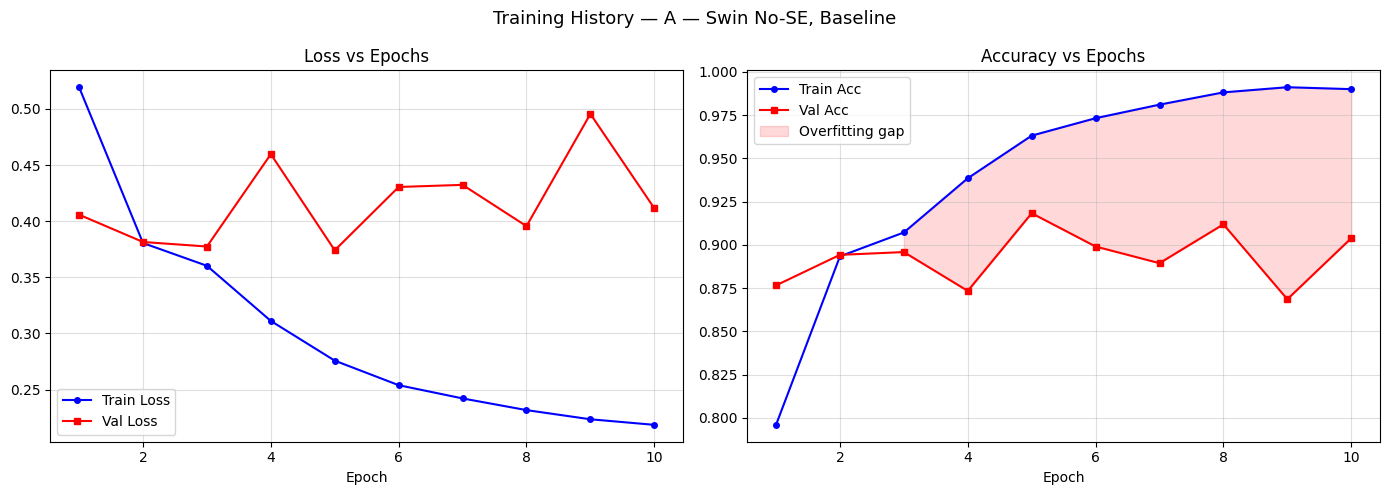


=== A: Swin No-SE Baseline ===
  Accuracy: 0.9183
  Precision: 0.9223
  Recall: 0.9183
  F1 Score: 0.9166
  Model Size (MB): 333.05
  Total Params (M): 87.27
  Trainable Params (M): 87.27

              precision    recall  f1-score   support

      NORMAL       0.96      0.81      0.88       234
   PNEUMONIA       0.90      0.98      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



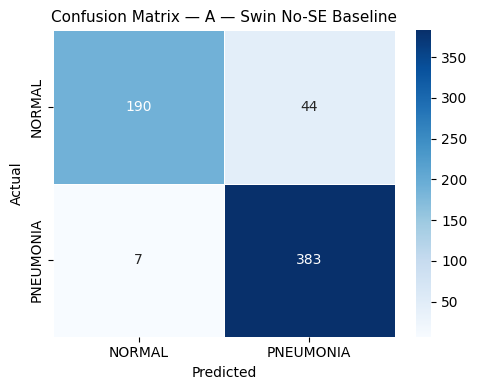

In [15]:
plot_history(hist_A, 'A — Swin No-SE, Baseline')
m_A = evaluate_model(model_A, test_loader, 'A: Swin No-SE Baseline')
m_A['Total Time (s)'] = hist_A['total_time']
m_A['Avg Epoch (s)']  = hist_A['avg_epoch']
plot_cm(m_A['Confusion Matrix'], 'A — Swin No-SE Baseline')

## Variant B — Swin + SE Block + Baseline
*(Ablation: SE effect)*

In [16]:
model_B, hist_B = train_variant(
    label='B_SwinSE_Base', train_loader=train_loader_base,
    use_se=True, epochs=15, lr=5e-5, patience=5,
    freeze_epochs=3, weight_decay=1e-3, label_smoothing=0.1, dropout=0.4
)


  B_SwinSE_Base  |  SE=True


  use_se=True | Total: 87.80M | Trainable: 87.80M
  Epoch 01/15 tr_loss=0.5003 tr_acc=0.8147 vl_loss=0.3938 vl_acc=0.8814 gap=-0.067 [97.8s]
  Epoch 02/15 tr_loss=0.3708 tr_acc=0.9042 vl_loss=0.3927 vl_acc=0.8766 gap=+0.028 [98.2s]
  Epoch 03/15 tr_loss=0.3471 tr_acc=0.9172 vl_loss=0.3791 vl_acc=0.8910 gap=+0.026 [98.0s]
  → Epoch 4: Unfreezing backbone (lr/10 for backbone)
  Epoch 04/15 tr_loss=0.3104 tr_acc=0.9415 vl_loss=0.4106 vl_acc=0.8926 gap=+0.049 [105.2s]
  Epoch 05/15 tr_loss=0.2795 tr_acc=0.9597 vl_loss=0.3831 vl_acc=0.8990 gap=+0.061 [106.8s]
  Epoch 06/15 tr_loss=0.2568 tr_acc=0.9709 vl_loss=0.4565 vl_acc=0.8782 gap=+0.093 [105.8s]
  Epoch 07/15 tr_loss=0.2429 tr_acc=0.9769 vl_loss=0.4423 vl_acc=0.8798 gap=+0.097 [104.9s]
  Epoch 08/15 tr_loss=0.2334 tr_acc=0.9843 vl_loss=0.4179 vl_acc=0.8958 gap=+0.089 [106.4s]
  Epoch 09/15 tr_loss=0.2233 tr_acc=0.9892 vl_loss=0.4747 vl_acc=0.8814 gap=+0.108 [106.8s]
  Epoch 10/15 tr_loss=0.2187 tr_acc=0.9914 vl_loss=0.4831 vl_acc=0.8766

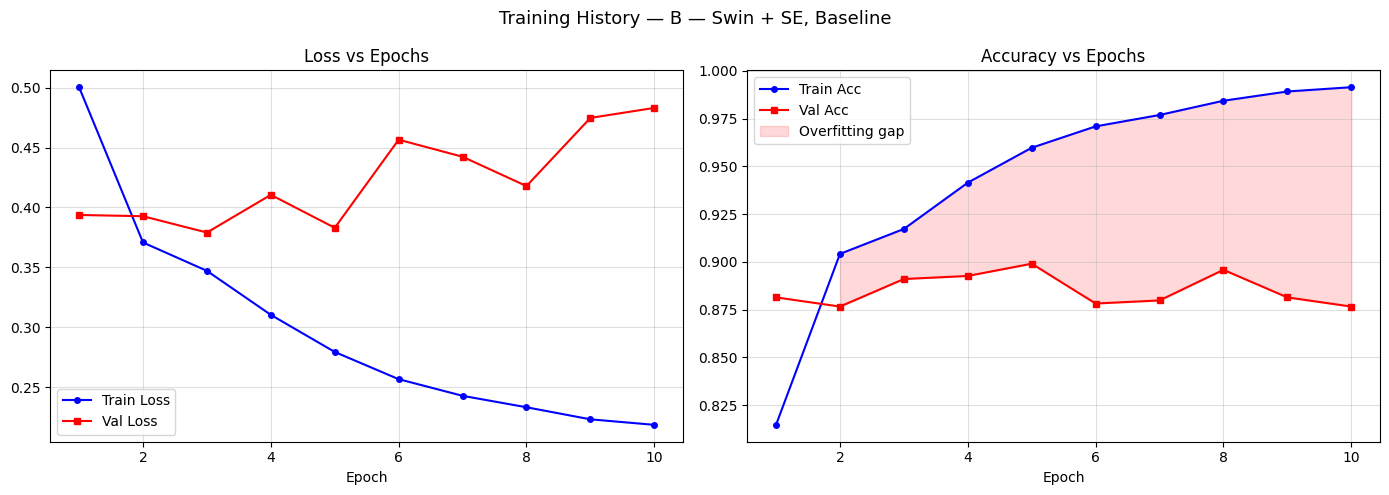


=== B: Swin + SE Baseline ===
  Accuracy: 0.899
  Precision: 0.9053
  Recall: 0.899
  F1 Score: 0.8963
  Model Size (MB): 335.06
  Total Params (M): 87.8
  Trainable Params (M): 87.8

              precision    recall  f1-score   support

      NORMAL       0.96      0.76      0.85       234
   PNEUMONIA       0.87      0.98      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624



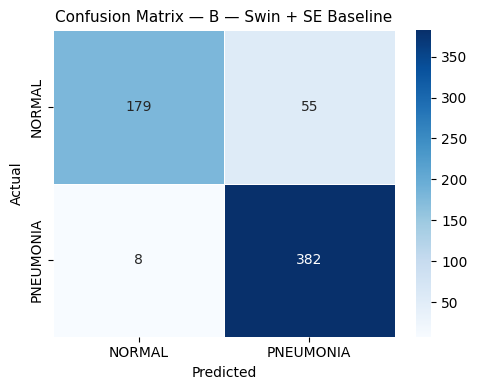

In [17]:
plot_history(hist_B, 'B — Swin + SE, Baseline')
m_B = evaluate_model(model_B, test_loader, 'B: Swin + SE Baseline')
m_B['Total Time (s)'] = hist_B['total_time']
m_B['Avg Epoch (s)']  = hist_B['avg_epoch']
plot_cm(m_B['Confusion Matrix'], 'B — Swin + SE Baseline')

## Variant C — Swin (No SE) + Augmented
*(Ablation: augmentation effect)*

In [18]:
model_C, hist_C = train_variant(
    label='C_SwinNoSE_Aug', train_loader=train_loader_aug,
    use_se=False, epochs=15, lr=5e-5, patience=5,
    freeze_epochs=3, weight_decay=1e-3, label_smoothing=0.1, dropout=0.4
)


  C_SwinNoSE_Aug  |  SE=False
  use_se=False | Total: 87.27M | Trainable: 87.27M
  Epoch 01/15 tr_loss=0.5994 tr_acc=0.7133 vl_loss=0.6139 vl_acc=0.7276 gap=-0.014 [109.7s]
  Epoch 02/15 tr_loss=0.4832 tr_acc=0.8304 vl_loss=0.6470 vl_acc=0.6554 gap=+0.175 [109.1s]
  Epoch 03/15 tr_loss=0.4376 tr_acc=0.8546 vl_loss=0.5651 vl_acc=0.7468 gap=+0.108 [108.4s]
  → Epoch 4: Unfreezing backbone (lr/10 for backbone)
  Epoch 04/15 tr_loss=0.3619 tr_acc=0.9072 vl_loss=0.4085 vl_acc=0.8622 gap=+0.045 [113.6s]
  Epoch 05/15 tr_loss=0.3119 tr_acc=0.9407 vl_loss=0.3800 vl_acc=0.8942 gap=+0.046 [114.7s]
  Epoch 06/15 tr_loss=0.2911 tr_acc=0.9526 vl_loss=0.3642 vl_acc=0.8990 gap=+0.054 [113.4s]
  Epoch 07/15 tr_loss=0.2851 tr_acc=0.9556 vl_loss=0.3803 vl_acc=0.8974 gap=+0.058 [114.1s]
  Epoch 08/15 tr_loss=0.2790 tr_acc=0.9582 vl_loss=0.3563 vl_acc=0.9022 gap=+0.056 [115.3s]
  Epoch 09/15 tr_loss=0.2694 tr_acc=0.9627 vl_loss=0.3496 vl_acc=0.9087 gap=+0.054 [114.2s]
  Epoch 10/15 tr_loss=0.2686 tr_acc=

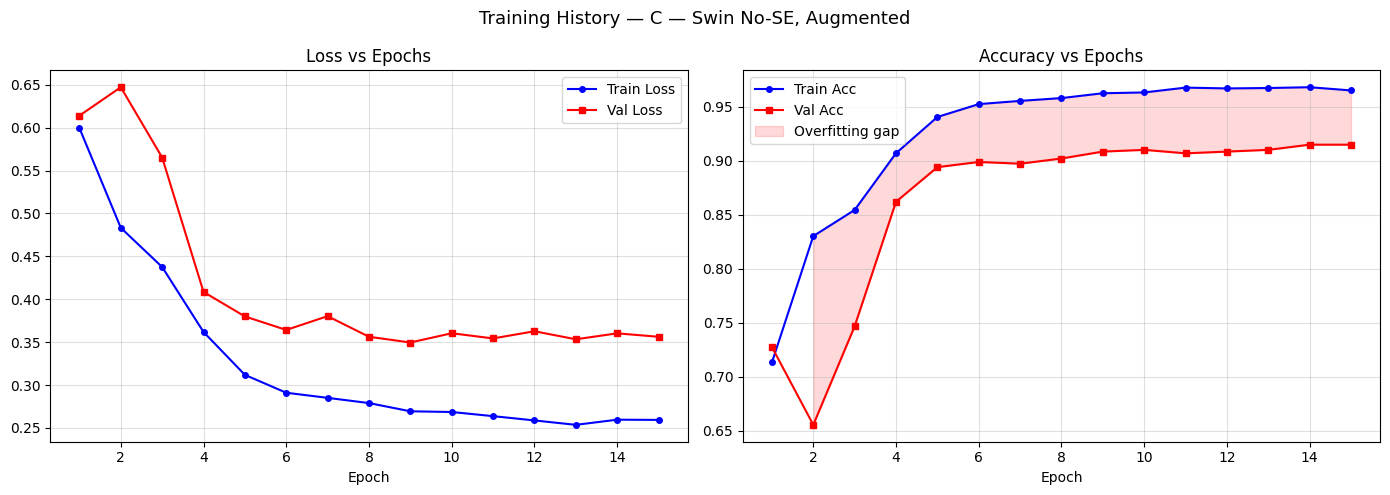


=== C: Swin No-SE Augmented ===
  Accuracy: 0.9151
  Precision: 0.9169
  Recall: 0.9151
  F1 Score: 0.9138
  Model Size (MB): 333.05
  Total Params (M): 87.27
  Trainable Params (M): 87.27

              precision    recall  f1-score   support

      NORMAL       0.94      0.82      0.88       234
   PNEUMONIA       0.90      0.97      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.91       624



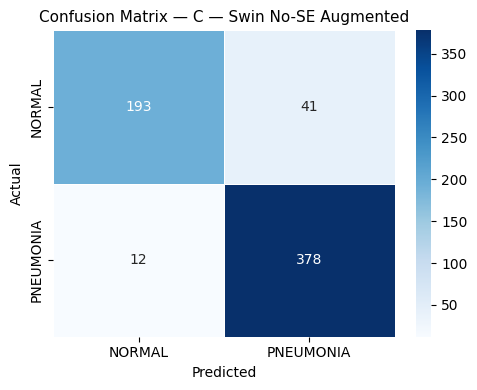

In [19]:
plot_history(hist_C, 'C — Swin No-SE, Augmented')
m_C = evaluate_model(model_C, test_loader, 'C: Swin No-SE Augmented')
m_C['Total Time (s)'] = hist_C['total_time']
m_C['Avg Epoch (s)']  = hist_C['avg_epoch']
plot_cm(m_C['Confusion Matrix'], 'C — Swin No-SE Augmented')

## Variant D — Swin + SE Block + Augmented ← Full Model

In [20]:
model_D, hist_D = train_variant(
    label='D_SwinSE_Aug', train_loader=train_loader_aug,
    use_se=True, epochs=15, lr=5e-5, patience=5,
    freeze_epochs=3, weight_decay=1e-3, label_smoothing=0.1, dropout=0.4
)


  D_SwinSE_Aug  |  SE=True
  use_se=True | Total: 87.80M | Trainable: 87.80M
  Epoch 01/15 tr_loss=0.5872 tr_acc=0.7133 vl_loss=0.5893 vl_acc=0.7436 gap=-0.030 [108.9s]
  Epoch 02/15 tr_loss=0.4744 tr_acc=0.8199 vl_loss=0.5236 vl_acc=0.8045 gap=+0.015 [108.0s]
  Epoch 03/15 tr_loss=0.4231 tr_acc=0.8572 vl_loss=0.4966 vl_acc=0.8189 gap=+0.038 [106.0s]
  → Epoch 4: Unfreezing backbone (lr/10 for backbone)
  Epoch 04/15 tr_loss=0.3718 tr_acc=0.8986 vl_loss=0.4065 vl_acc=0.8734 gap=+0.025 [114.2s]
  Epoch 05/15 tr_loss=0.3111 tr_acc=0.9407 vl_loss=0.3990 vl_acc=0.8830 gap=+0.058 [115.6s]
  Epoch 06/15 tr_loss=0.3019 tr_acc=0.9441 vl_loss=0.3945 vl_acc=0.8734 gap=+0.071 [115.5s]
  Epoch 07/15 tr_loss=0.2822 tr_acc=0.9564 vl_loss=0.3678 vl_acc=0.8990 gap=+0.057 [114.3s]
  Epoch 08/15 tr_loss=0.2785 tr_acc=0.9582 vl_loss=0.3634 vl_acc=0.9038 gap=+0.054 [113.8s]
  Epoch 09/15 tr_loss=0.2693 tr_acc=0.9650 vl_loss=0.4053 vl_acc=0.8878 gap=+0.077 [114.9s]
  Epoch 10/15 tr_loss=0.2655 tr_acc=0.96

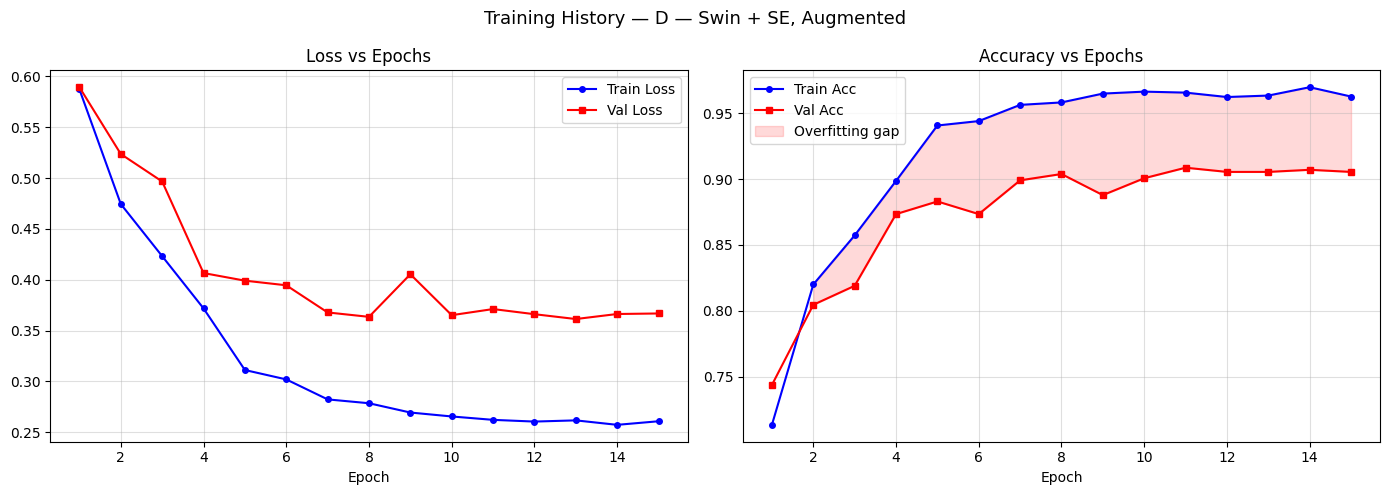


=== D: Swin + SE Augmented ===
  Accuracy: 0.9087
  Precision: 0.9116
  Recall: 0.9087
  F1 Score: 0.9069
  Model Size (MB): 335.06
  Total Params (M): 87.8
  Trainable Params (M): 87.8

              precision    recall  f1-score   support

      NORMAL       0.94      0.80      0.87       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



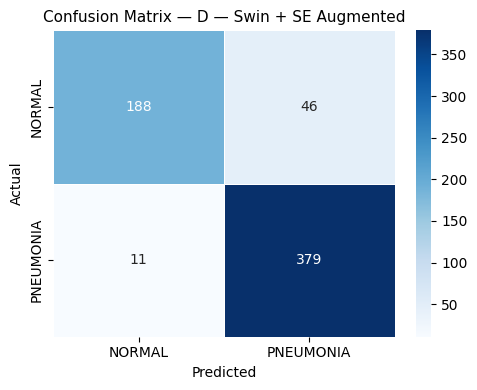

In [21]:
plot_history(hist_D, 'D — Swin + SE, Augmented')
m_D = evaluate_model(model_D, test_loader, 'D: Swin + SE Augmented')
m_D['Total Time (s)'] = hist_D['total_time']
m_D['Avg Epoch (s)']  = hist_D['avg_epoch']
plot_cm(m_D['Confusion Matrix'], 'D — Swin + SE Augmented')

---
## Results Table

In [22]:
ablation = [
    ('A', 'No',  'Baseline',  m_A),
    ('B', 'Yes', 'Baseline',  m_B),
    ('C', 'No',  'Augmented', m_C),
    ('D', 'Yes', 'Augmented', m_D),
]
rows = []
for v, se, prep, m in ablation:
    rows.append({
        'Var': v, 'SE': se, 'Preprocessing': prep,
        'Accuracy' : m['Accuracy'],
        'Precision': m['Precision'],
        'Recall'   : m['Recall'],
        'F1 Score' : m['F1 Score'],
        'Size(MB)' : m['Model Size (MB)'],
        'Params(M)': m['Total Params (M)'],
        'Time(s)'  : m['Total Time (s)'],
        'Avg Ep(s)': m['Avg Epoch (s)'],
    })

res_df = pd.DataFrame(rows)
print('\n========= ABLATION RESULTS =========')
print(res_df.to_string(index=False))
res_df.to_csv('/kaggle/working/ablation_results.csv', index=False)


========= ABLATION RESULTS =========
Var  SE Preprocessing  Accuracy  Precision  Recall  F1 Score  Size(MB)  Params(M)  Time(s)  Avg Ep(s)
  A  No      Baseline    0.9183     0.9223  0.9183    0.9166    333.05      87.27   1039.0      103.9
  B Yes      Baseline    0.8990     0.9053  0.8990    0.8963    335.06      87.80   1033.7      103.4
  C  No     Augmented    0.9151     0.9169  0.9151    0.9138    333.05      87.27   1696.6      113.1
  D Yes     Augmented    0.9087     0.9116  0.9087    0.9069    335.06      87.80   1701.4      113.4


## Comparison Plots

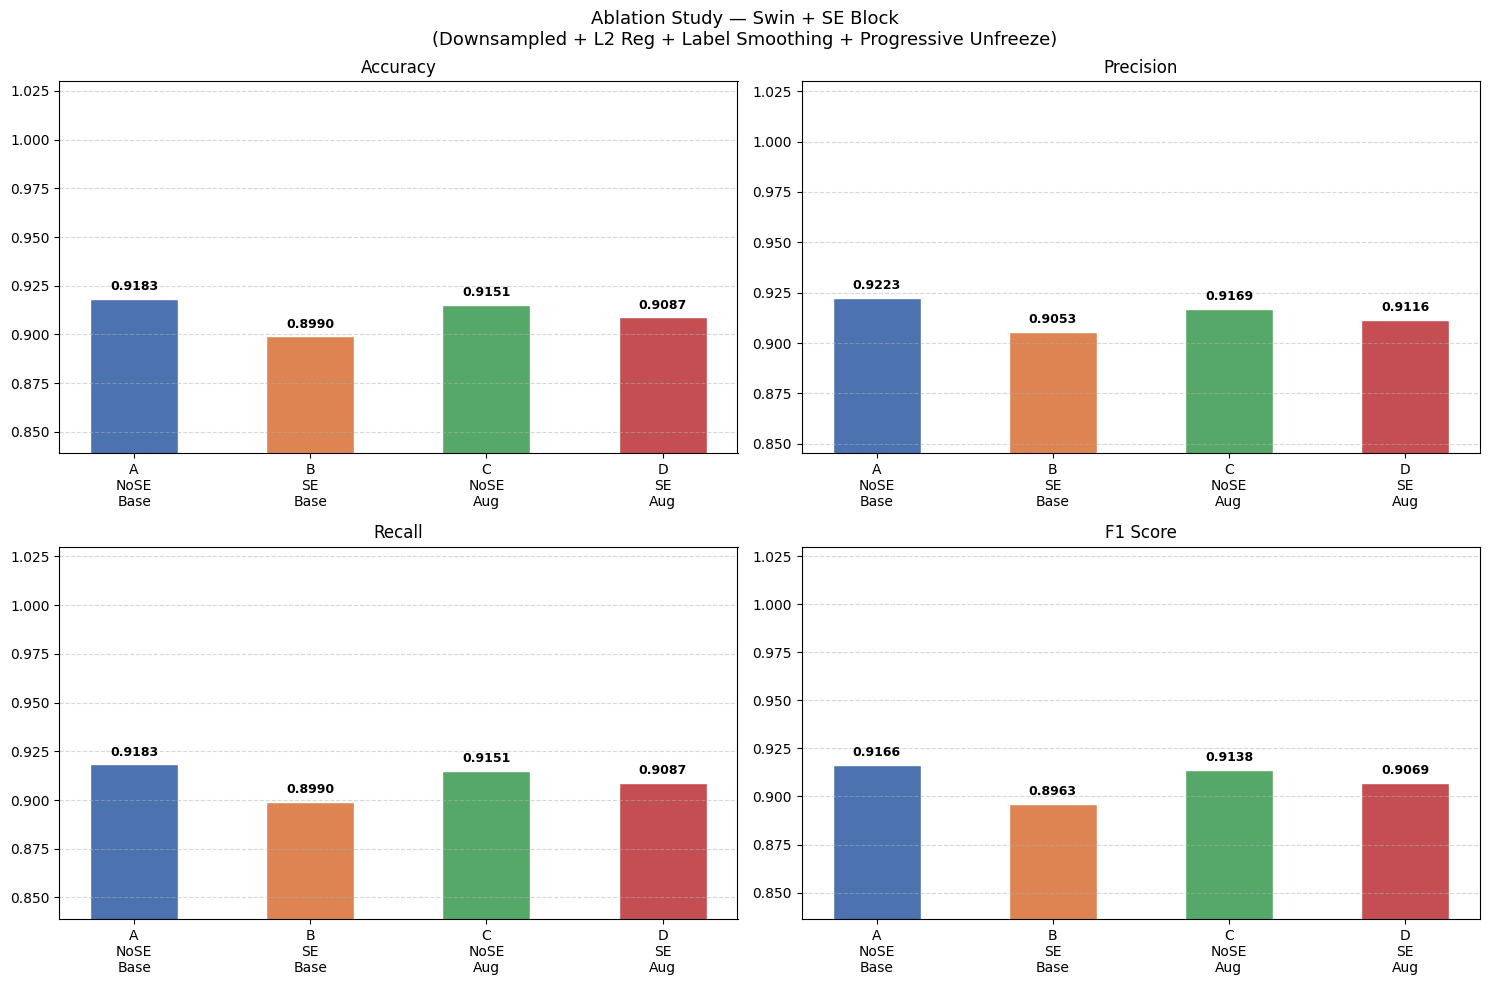

In [23]:
# ── Bar charts ────────────────────────────────────────────────────────────────
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
short  = ['A\nNoSE\nBase','B\nSE\nBase','C\nNoSE\nAug','D\nSE\nAug']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Ablation Study — Swin + SE Block\n'
             '(Downsampled + L2 Reg + Label Smoothing + Progressive Unfreeze)',
             fontsize=13)
for ax, metric in zip(axes.flat, ['Accuracy','Precision','Recall','F1 Score']):
    vals = res_df[metric].values
    bars = ax.bar(short, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=12)
    lo = max(0, vals.min()-0.06)
    ax.set_ylim(lo, 1.03)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

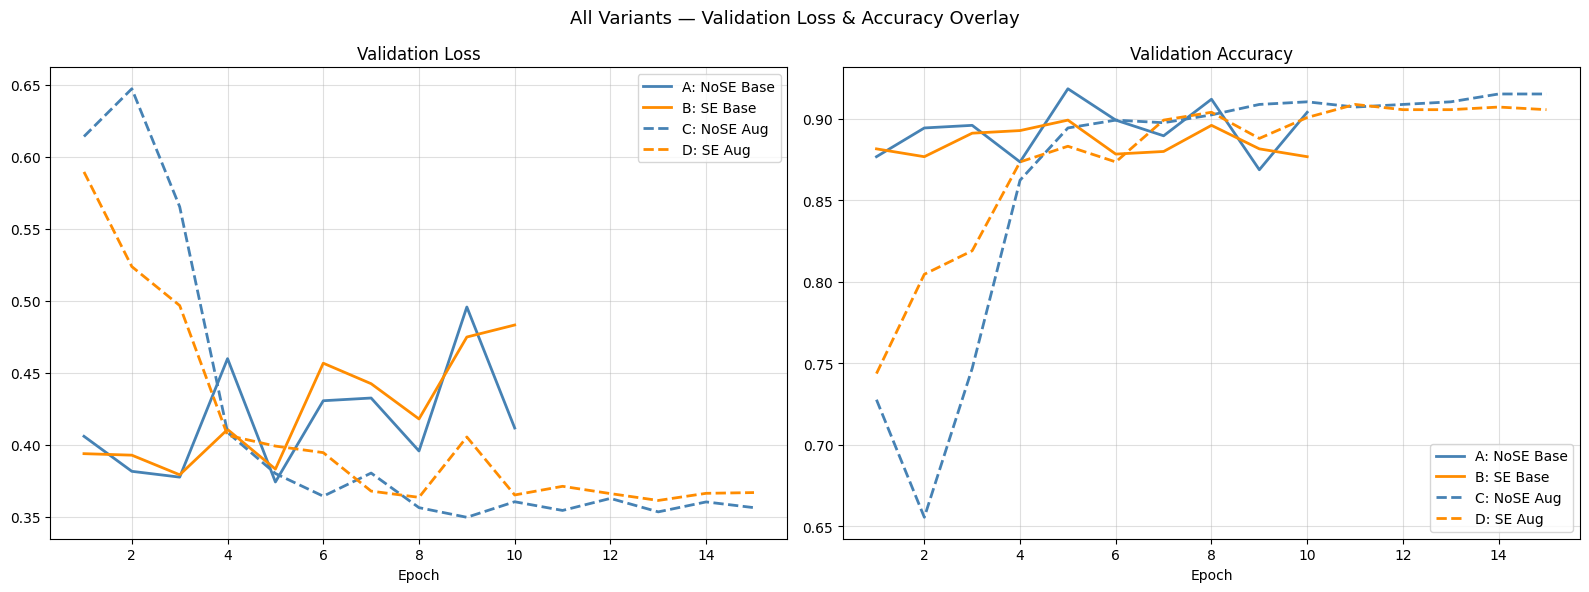

In [24]:
# ── Overlay curves ────────────────────────────────────────────────────────────
histories  = [hist_A, hist_B, hist_C, hist_D]
var_labels = ['A: NoSE Base','B: SE Base','C: NoSE Aug','D: SE Aug']
styles     = [('steelblue','-'),('darkorange','-'),
              ('steelblue','--'),('darkorange','--')]

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('All Variants — Validation Loss & Accuracy Overlay', fontsize=13)
for h, lbl, (col, ls) in zip(histories, var_labels, styles):
    ep = range(1, len(h['train_loss'])+1)
    axes[0].plot(ep, h['val_loss'],  color=col, ls=ls, lw=2, label=lbl)
    axes[1].plot(ep, h['val_acc'],   color=col, ls=ls, lw=2, label=lbl)
axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()

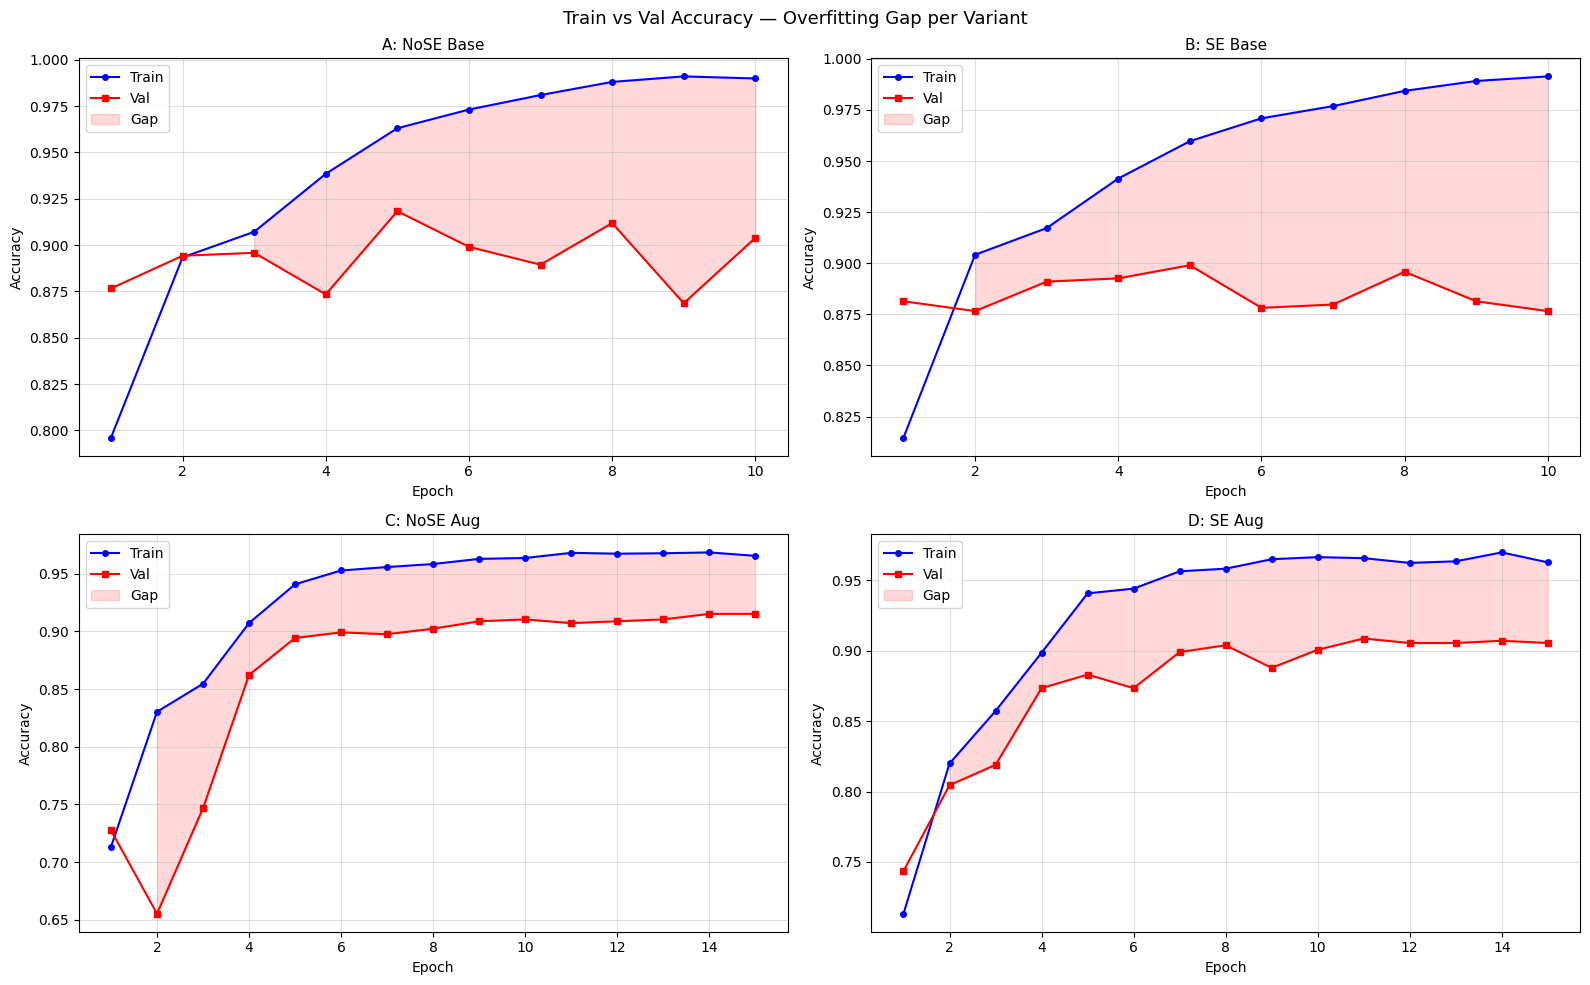

In [25]:
# ── Overfitting gap per variant ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Train vs Val Accuracy — Overfitting Gap per Variant', fontsize=13)
for ax, h, lbl in zip(axes.flat, histories, var_labels):
    ep  = list(range(1, len(h['train_acc'])+1))
    tr  = np.array(h['train_acc'])
    vl  = np.array(h['val_acc'])
    ax.plot(ep, tr, 'b-o', ms=4, label='Train')
    ax.plot(ep, vl, 'r-s', ms=4, label='Val')
    ax.fill_between(ep, vl, tr, where=(tr>vl),
                    alpha=0.15, color='red', label='Gap')
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

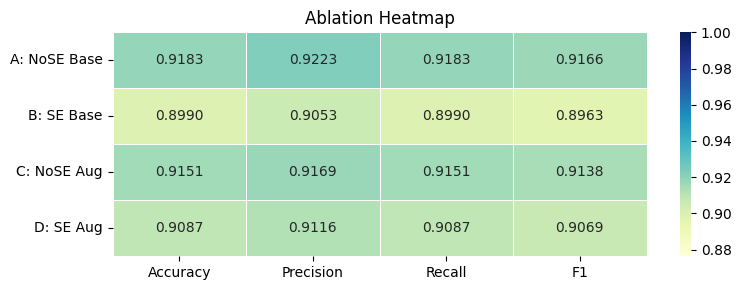

In [26]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
heat = res_df[['Accuracy','Precision','Recall','F1 Score']].values
fig, ax = plt.subplots(figsize=(8,3))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=['Accuracy','Precision','Recall','F1'],
            yticklabels=['A: NoSE Base','B: SE Base',
                         'C: NoSE Aug','D: SE Aug'],
            vmin=heat.min()-0.02, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('Ablation Heatmap', fontsize=12)
plt.tight_layout(); plt.show()

## Final Summary

In [27]:
print('='*65)
print('FINAL ABLATION SUMMARY')
print('='*65)
print(res_df[['Var','SE','Preprocessing','Accuracy',
              'F1 Score','Params(M)','Size(MB)']].to_string(index=False))

best = res_df.loc[res_df['Accuracy'].idxmax()]
print(f'\n✅  Best : Variant {best["Var"]} '
      f'(SE={best["SE"]}, {best["Preprocessing"]})')
print(f'    Accuracy : {best["Accuracy"]}')
print(f'    F1       : {best["F1 Score"]}')

print('\n--- Ablation Delta Analysis ---')
print(f'SE effect  (Baseline)  : {res_df.loc[1,"Accuracy"]-res_df.loc[0,"Accuracy"]:+.4f}')
print(f'SE effect  (Augmented) : {res_df.loc[3,"Accuracy"]-res_df.loc[2,"Accuracy"]:+.4f}')
print(f'Aug effect (No SE)     : {res_df.loc[2,"Accuracy"]-res_df.loc[0,"Accuracy"]:+.4f}')
print(f'Aug effect (+SE)       : {res_df.loc[3,"Accuracy"]-res_df.loc[1,"Accuracy"]:+.4f}')

FINAL ABLATION SUMMARY
Var  SE Preprocessing  Accuracy  F1 Score  Params(M)  Size(MB)
  A  No      Baseline    0.9183    0.9166      87.27    333.05
  B Yes      Baseline    0.8990    0.8963      87.80    335.06
  C  No     Augmented    0.9151    0.9138      87.27    333.05
  D Yes     Augmented    0.9087    0.9069      87.80    335.06

✅  Best : Variant A (SE=No, Baseline)
    Accuracy : 0.9183
    F1       : 0.9166

--- Ablation Delta Analysis ---
SE effect  (Baseline)  : -0.0193
SE effect  (Augmented) : -0.0064
Aug effect (No SE)     : -0.0032
Aug effect (+SE)       : +0.0097
